# Sales Data Analysis with pandas & NumPy

An end-to-end exploratory data analysis (EDA) on a fictional 2024 sales dataset.
This notebook walks through the full workflow an analyst uses on any new dataset:

1. **Load** the raw data
2. **Assess** its quality (nulls, duplicates, inconsistencies, outliers)
3. **Clean** it into a reliable shape
4. **Analyze** it with pandas grouping and NumPy
5. **Visualize** the findings

*Data is fictional and generated purely for demonstration.*

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('sales_data.csv', parse_dates=['month'])
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 145 rows, 5 columns


,month,region,category,revenue,units
0,2024-01-01,North,Fonts,14313.61,146.0
1,2024-01-01,North,Bundles,9833.58,91.0
2,2024-01-01,North,Licenses,4502.48,37.0
3,2024-01-01,South,Fonts,14247.48,127.0
4,2024-01-01,South,Bundles,7320.71,74.0


## 2. Assess data quality

Before trusting any numbers, check what's wrong with the raw data.

In [2]:
# Overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   month     145 non-null    datetime64[us]
 1   region    145 non-null    str           
 2   category  145 non-null    str           
 3   revenue   144 non-null    float64       
 4   units     144 non-null    float64       
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 5.8 KB


In [3]:
# Missing values per column
print("Missing values:")
print(df.isna().sum())

# Duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Inconsistent categorical values (note casing / whitespace issues)
print(f"\nUnique regions (raw): {df['region'].unique()}")

Missing values:
month       0
region      0
category    0
revenue     1
units       1
dtype: int64

Duplicate rows: 1

Unique regions (raw): <StringArray>
['North', 'South', 'north', 'East', 'West', ' South ']
Length: 6, dtype: str


In [4]:
# Spot outliers in revenue using summary stats
df['revenue'].describe()

count       144.000000
mean      15119.487847
std       82709.847981
min        3511.420000
25%        5337.605000
50%        7802.610000
75%       10836.860000
max      999999.000000
Name: revenue, dtype: float64

## 3. Clean the data

Fix each issue found above:
- Standardize `region` text (strip whitespace, title-case)
- Drop duplicate rows
- Fill missing `revenue` / `units` with the median for that category
- Cap the revenue outlier using the IQR method

In [5]:
df_clean = df.copy()

# 3a. Standardize region text
df_clean['region'] = df_clean['region'].str.strip().str.title()
print("Regions after cleaning:", df_clean['region'].unique())

# 3b. Remove duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} duplicate row(s)")

Regions after cleaning: <StringArray>
['North', 'South', 'East', 'West']
Length: 4, dtype: str
Dropped 1 duplicate row(s)


In [6]:
# 3c. Fill missing values with category median (a defensible default)
for col in ['revenue', 'units']:
    df_clean[col] = df_clean.groupby('category')[col].transform(
        lambda s: s.fillna(s.median())
    )
print("Missing values after fill:")
print(df_clean[['revenue','units']].isna().sum())

Missing values after fill:
revenue    0
units      0
dtype: int64


In [7]:
# 3d. Cap revenue outliers using the IQR method (NumPy for the math)
q1, q3 = np.percentile(df_clean['revenue'], [25, 75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_out = (df_clean['revenue'] > upper).sum()
df_clean['revenue'] = np.where(df_clean['revenue'] > upper, upper, df_clean['revenue'])
print(f"Capped {n_out} outlier(s) at upper bound = {upper:,.0f}")

Capped 1 outlier(s) at upper bound = 19,205


## 4. Analyze

With clean data, answer some business questions.

In [8]:
# Total revenue by region
region_rev = (df_clean.groupby('region')['revenue']
              .sum().sort_values(ascending=False))
print("Total revenue by region:")
print(region_rev.round(0))

Total revenue by region:
region
South    303754.0
West     298759.0
North    298708.0
East     291707.0
Name: revenue, dtype: float64


In [9]:
# Revenue share by category (NumPy for the percentage math)
cat_rev = df_clean.groupby('category')['revenue'].sum()
cat_share = np.round(cat_rev / cat_rev.sum() * 100, 1)
print("Revenue share by category (%):")
print(cat_share)

Revenue share by category (%):
category
Bundles     31.2
Fonts       48.0
Licenses    20.8
Name: revenue, dtype: float64


In [10]:
# Monthly revenue trend (all regions combined)
monthly = df_clean.groupby('month')['revenue'].sum()
print("Monthly revenue (2024):")
print(monthly.round(0))

Monthly revenue (2024):
month
2024-01-01    113321.0
2024-02-01    112538.0
2024-03-01    115139.0
2024-04-01    109378.0
2024-05-01    115368.0
2024-06-01     99200.0
2024-07-01     89980.0
2024-08-01     87417.0
2024-09-01     78919.0
2024-10-01     86820.0
2024-11-01     90013.0
2024-12-01     94837.0
Name: revenue, dtype: float64


## 5. Visualize

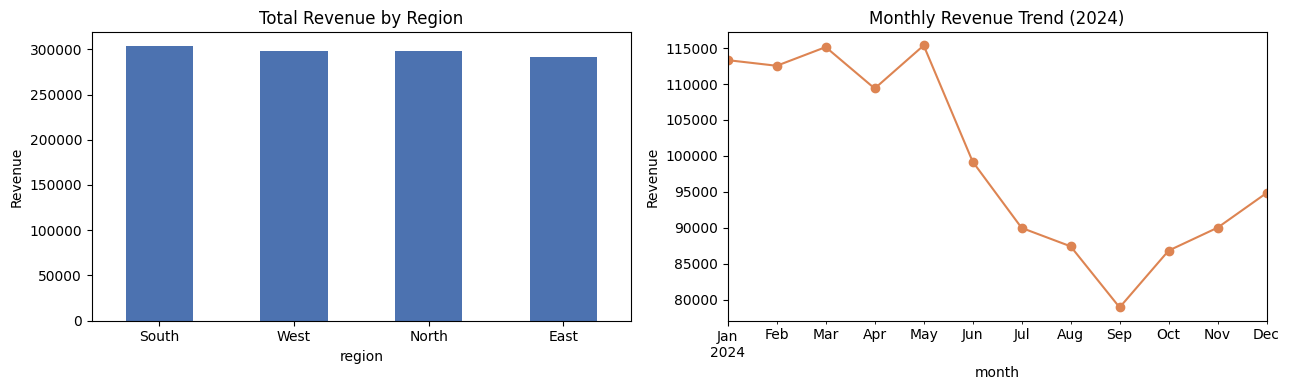

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Revenue by region
region_rev.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Total Revenue by Region')
axes[0].set_ylabel('Revenue')
axes[0].tick_params(axis='x', rotation=0)

# Monthly trend
monthly.plot(kind='line', marker='o', ax=axes[1], color='#DD8452')
axes[1].set_title('Monthly Revenue Trend (2024)')
axes[1].set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('revenue_charts.png', dpi=90, bbox_inches='tight')
plt.show()

## Summary

- Started with 145 raw rows containing missing values, a duplicate, inconsistent region labels, and a revenue outlier.
- Cleaned to a reliable dataset: standardized text, removed the duplicate, median-filled nulls per category, and capped the outlier with the IQR method.
- **Findings:** revenue is fairly balanced across regions, Fonts is the largest category by share, and monthly revenue follows a mild seasonal pattern.

The same workflow — assess, clean, analyze, visualize — applies to almost any tabular dataset.